<img src="https://assets-datascientest.s3-eu-west-1.amazonaws.com/train/logo_datascientest.png" style="height:150px">

<hr style="border-width:2px;border-color:#75DFC1">

<center><h1> ORT : Exploration de la donnée fournie par le commanditaire </h1></center>

<hr style="border-width:2px;border-color:#75DFC1">

>**Notre commanditaire** nous a fourni un fichier CSV contenant des mesures de la couverture corallienne sur plusieurs récifs. Son objectif est d’étudier l’évolution de cette couverture au fil du temps et d’en prédire les tendances futures.
>
> Nous disposons d’une semaine pour réaliser une première analyse. Dans un premier temps, il est essentiel d’explorer rapidement les données afin de mieux les comprendre. Pour cela, nous pouvons nous appuyer sur la documentation fournie par le commanditaire.
> 
> Notre démarche consiste donc à examiner les données en détail, identifier les éventuels problèmes, incohérences ou zones d’ombre, ainsi que les premières problématiques d’analyse.
> 
> À l’issue de cette phase exploratoire, nous aurons l’opportunité de rencontrer deux interlocuteurs clés : un chef de projet du ministère de l’Environnement en Australie et un biologiste ayant participé à la collecte des données. Il est donc crucial de préparer cette rencontre en identifiant en amont les points peu clairs ou problématiques, afin de pouvoir poser des questions pertinentes.
>
> Ces échanges nous permettront de mieux comprendre à la fois les données et les attentes du commanditaire.
>
> Ainsi, nous devrons arriver à ces rendez-vous avec :
>
> - **des questions précises sur les données**,
> - **une meilleure compréhension du besoin métier**,
> - **ainsi qu’une première proposition d’axes d’analyse**.
>
> Nous commençons donc par examiner les données :
> il s’agit notamment de comprendre leur structure (en particulier leur organisation hiérarchique), la nature des variables, ainsi que leur contenu global.
>
> Pour cela, nous allons importer les bibliothèques nécessaires et débuter l’exploration des données.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('GBR_ltmp.csv')
df.head(5)

,REEF_ID,REEF_NAME,A_SECTOR,SHELF,LAT,LON,SITE_LAT,SITE_LON,SITE_NO,TRANSECT_NO,REPORT_YEAR,COVER,DISTURBANCE,COTS,STORM,BLEACHING,DISEASE,C,S,B,D,BENT_CLUST,CLUSTER,CONNECTEDNESS,AREA,RST,RSTY,HC,HC_1,HERB,HERB2,iZONE,sZONE,PFp,PFs,PFt,PFsum
0,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1995,15.29,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1995,15.29,-999.00,36,18,1,0,0.004542,0.016747,0.116079,0.137369
1,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1996,28.39,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1996,28.39,15.29,42,11,1,0,0.004542,0.016747,0.116079,0.137369
2,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1997,21.50,C,1,0,0,0,0.533,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1997,21.50,28.39,40,22,1,0,0.004542,0.016747,0.116079,0.137369
3,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1998,22.50,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1998,22.50,21.50,58,28,1,0,0.004542,0.016747,0.116079,0.137369
4,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1999,22.38,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1999,22.38,22.50,30,13,1,0,0.004542,0.016747,0.116079,0.137369


> Nous allons à présent entamer la phase d’exploration des données, dont l’objectif est de mieux comprendre le jeu de données ainsi que ses éventuelles limites. Cette étape consiste tout d’abord à appréhender sa structure générale, notamment en identifiant le nombre de lignes et de colonnes.
> 
> Nous chercherons également à détecter **la présence de doublons** ainsi que d’éventuelles **valeurs manquantes**, afin d’évaluer la qualité globale des données. Une attention particulière sera portée à la compréhension des variables : il s’agira d’identifier **d’éventuelles redondances** ou des variables véhiculant une information similaire.
>
> Enfin, nous nous attacherons à analyser la **structure imbriquée des données**, afin de mieux comprendre leur organisation hiérarchique et les relations entre les différentes variables.

In [2]:
print(f'Nos données contiennent {df.shape[0]} lignes et {df.shape[1]} colonnes')
print(f'Nos données contiennent {df.duplicated().sum()} doublons')
print(f'Nos données contiennent {df.isna().sum().sum()} valeurs manquantes')
print(f'Nos données contiennent {df.duplicated().sum()} doublons')

df.isna().sum().sort_values(ascending = False).head(5)

Nos données contiennent 15870 lignes et 37 colonnes
Nos données contiennent 0 doublons
Nos données contiennent 35 valeurs manquantes
Nos données contiennent 0 doublons


DISTURBANCE    30
COVER           5
A_SECTOR        0
REEF_NAME       0
REEF_ID         0
dtype: int64

> À l’issue de cette première analyse, nous constatons que le jeu de données contient très peu de valeurs manquantes.
>
> Nous nous intéressons à présent aux variables susceptibles de jouer le rôle de variables dépendantes. Les variables `COVER` et `HC` semblent a priori porter une information similaire. Il convient donc de vérifier cette hypothèse en comparant leurs valeurs respectives et en analysant leurs distributions, notamment à l’aide d’histogrammes.

Même type : True
Égalité stricte : True
La moyenne de la variable HC est -188.3316255909234 et son écart-type est 419.4815576614509
La moyenne de la variable COVER est -188.3316255909234 et son écart-type est 419.4815576614509


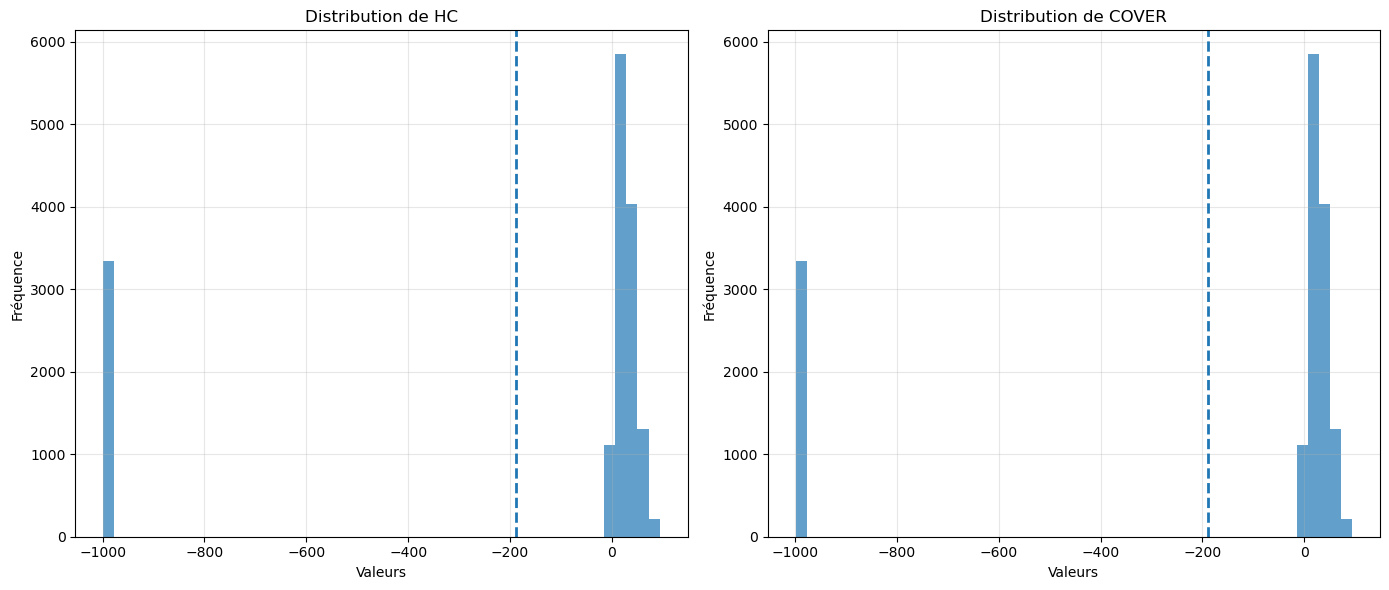

In [3]:
df_cover_hc = df.dropna(subset = ['COVER'])
print("Même type :", df_cover_hc["COVER"].dtype == df_cover_hc["HC"].dtype)
print("Égalité stricte :", df_cover_hc["COVER"].equals(df_cover_hc["HC"]))

print(f'La moyenne de la variable HC est {df_cover_hc.HC.mean()} et son écart-type est {df_cover_hc.HC.std()}')
print(f'La moyenne de la variable COVER est {df_cover_hc.COVER.mean()} et son écart-type est {df_cover_hc.COVER.std()}')

mean_hc = df["HC"].mean()
mean_cover = df["COVER"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(df["HC"], bins=50, alpha=0.7)
axes[0].axvline(mean_hc, linestyle="dashed", linewidth=2)
axes[0].set_title("Distribution de HC")
axes[0].set_xlabel("Valeurs")
axes[0].set_ylabel("Fréquence")
axes[0].grid(alpha=0.3)

axes[1].hist(df["COVER"], bins=50, alpha=0.7)
axes[1].axvline(mean_cover, linestyle="dashed", linewidth=2)
axes[1].set_title("Distribution de COVER")
axes[1].set_xlabel("Valeurs")
axes[1].set_ylabel("Fréquence")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

> Les valeurs `-999` apparaissent dans plusieurs colonnes, y compris dans des colonnes catégorielles. Nous faisons l’hypothèse que ces valeurs représentent des données manquantes, ce qui devra être confirmé auprès d’un responsable métier.

In [4]:
print(f'la valeur la plus faible sur la variable HC est {df['HC'].min()}')

df.replace({-999.0 : np.nan}, inplace = True)
df.isna().sum().sort_values(ascending = False).head(15)


la valeur la plus faible sur la variable HC est -999.0


HC_1           4037
HERB2          3527
COVER          3352
D              3347
DISEASE        3347
STORM          3347
HC             3347
COTS           3347
S              3347
B              3347
BLEACHING      3347
C              3337
HERB           1380
DISTURBANCE      30
LAT               0
dtype: int64

> Nous analyserons ensuite la répartition de ces valeurs manquantes afin de déterminer la stratégie de traitement la plus appropriée.
>
> De manière générale, dans une démarche prédictive, il est important de ne pas introduire de biais en imputant de nouvelles valeurs pour remplacer les valeurs manquantes de la variable cible.
>
> En conséquence, nous avons décidé **d’éliminer, pour l’instant**, toutes les lignes contenant des valeurs manquantes sur la variable cible et de poursuivre l’exploration des données. Dans un second temps, nous pourrons envisager des solutions adaptées pour traiter ces valeurs manquantes si nécessaire.
>
> Par ailleurs, nous examinerons, à l’aide d’un graphique en lignes (line plot), si le nombre d’observations est relativement constant au fil des années ou si certaines années présentent un nombre d’enregistrements plus élevé.

(12523, 37)


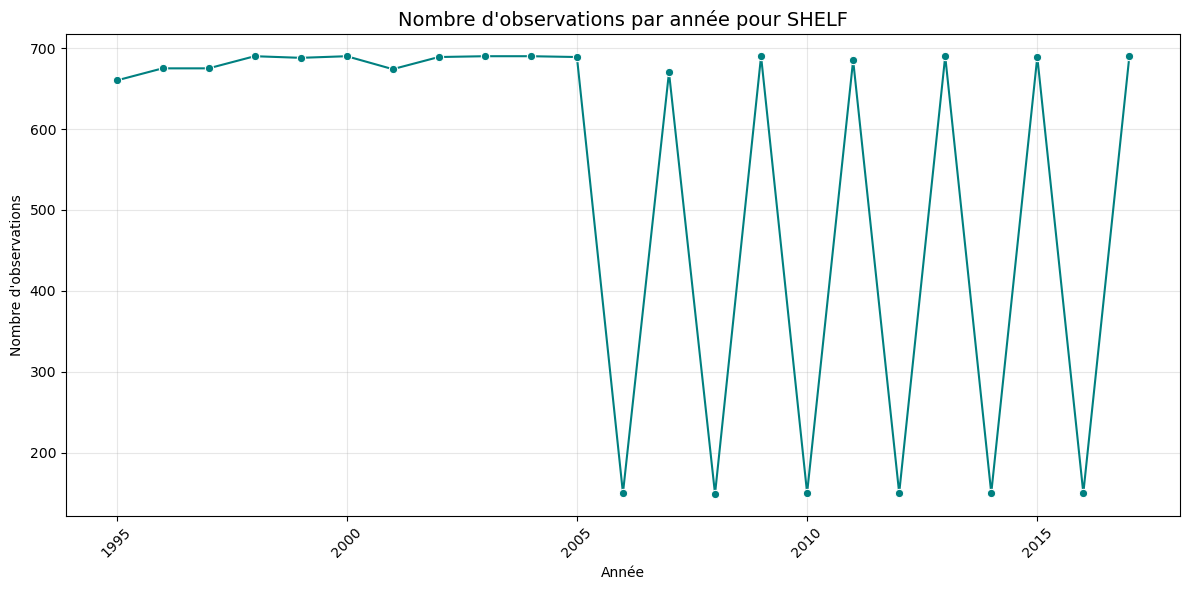

In [5]:
df_data_viz = df.copy()

df.dropna(subset = ['HC'], inplace = True)
print(df.shape)

shelf_per_year = df.groupby('REPORT_YEAR')['SHELF'].count().reset_index()

shelf_per_year.columns = ['Year', 'N_observations']

plt.figure(figsize=(12,6))
sns.lineplot(data=shelf_per_year, x='Year', y='N_observations', marker='o', color='teal')
plt.title("Nombre d'observations par année pour SHELF", fontsize=14)
plt.xlabel("Année")
plt.ylabel("Nombre d'observations")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> Nous constatons qu’à partir de **2006**, le nombre d’observations diminue de manière régulière une année sur deux.
>
> Il est important de comprendre les raisons de cette variation : pourquoi, à partir de cette date, certaines années présentent-elles nettement moins d’enregistrements ?
>
> Pour approfondir cette analyse, nous proposons d’examiner le nombre de mesures de manière plus granulaire, par exemple en les segmentant par **secteur géographique**, afin d’identifier d’éventuelles causes ou tendances spécifiques.

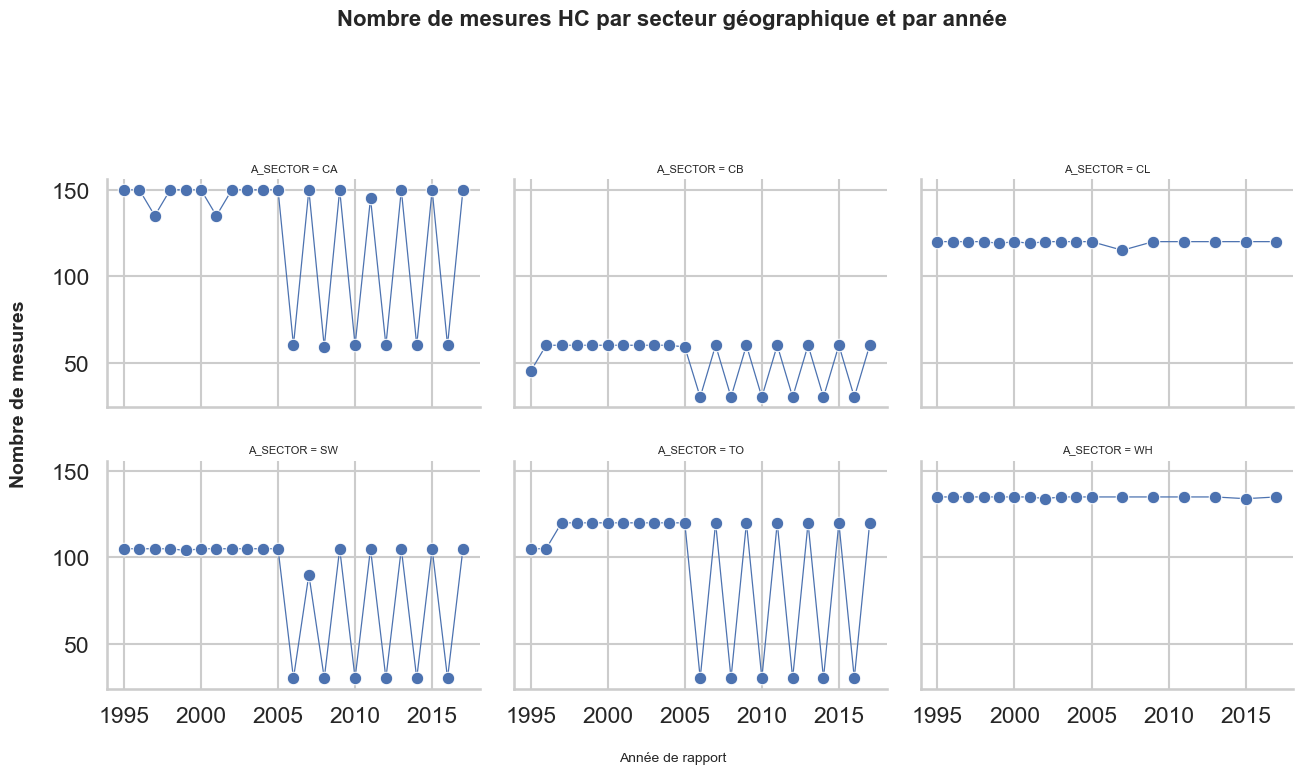

In [6]:
shelf_per_year = (
    df.groupby(['REPORT_YEAR', 'A_SECTOR'])['HC']
      .count()
      .reset_index(name='N_measures')
)

sns.set_theme(style="whitegrid", context="talk")

g = sns.relplot(
    x='REPORT_YEAR',
    y='N_measures',
    col='A_SECTOR',
    data=shelf_per_year,
    kind='line',
    col_wrap=3,
    height=4,
    aspect=1.2,
    marker='o',
    linewidth=0.9
)

g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Nombre de mesures HC par secteur géographique et par année", fontsize=16, weight='bold')

for ax in g.axes.flatten():
    ax.set_title(ax.get_title(), fontsize=8)

for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')

g.fig.text(0.5, 0.04, "Année de rapport", ha='center', fontsize=10) 
g.fig.text(0.04, 0.5, "Nombre de mesures", va='center', rotation='vertical', fontsize=14, weight='bold')

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.88]) 
plt.show()

> Nous constatons que le nombre d’observations varie de manière significative pour l’ensemble des secteurs géographiques, et qu’il reste relativement constant uniquement dans les secteurs `CL` et `WH`. Cependant, il semble que, même dans ces deux secteurs, les mesures aient été réalisées seulement une année sur deux.
>
> Pour vérifier cette hypothèse, nous allons examiner le nombre d’observations par **récif** afin d’identifier plus précisément les tendances et éventuelles régularités dans la collecte des données.

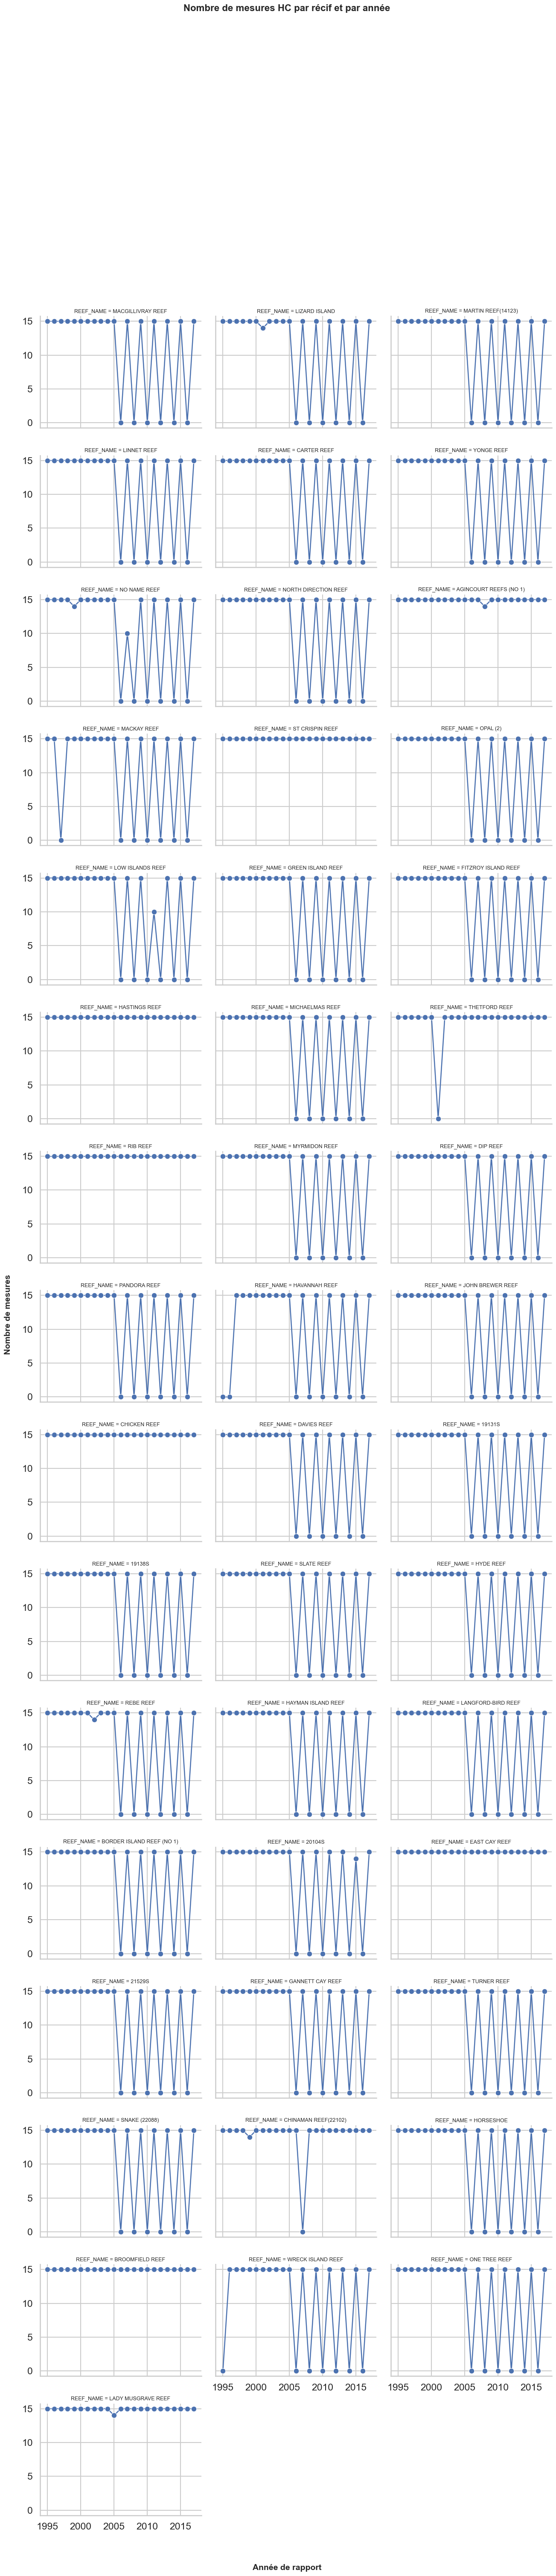

In [7]:
shelf_per_year = (
    df_data_viz.groupby(['REPORT_YEAR', 'REEF_NAME'])['HC']
      .count()
      .reset_index(name='N_measures')
)

years = df_data_viz['REPORT_YEAR'].unique()
sectors = df_data_viz['REEF_NAME'].unique()

full_index = pd.MultiIndex.from_product(
    [years, sectors],
    names=['REPORT_YEAR', 'REEF_NAME']
)

shelf_per_year = (
    shelf_per_year
    .set_index(['REPORT_YEAR', 'REEF_NAME'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

sns.set_theme(style="whitegrid", context="talk")

g = sns.relplot(
    data=shelf_per_year,
    x='REPORT_YEAR',
    y='N_measures',
    col='REEF_NAME',
    kind='line',
    col_wrap=3,
    height=4,
    aspect=1.2,
    marker='o',
    linewidth=1.8
)


g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Nombre de mesures HC par récif et par année", fontsize=16, weight='bold')

for ax in g.axes.flatten():
    ax.set_title(ax.get_title(), fontsize=9)  
    ax.set_xlabel('') 
    ax.set_ylabel('') 

g.fig.text(0.5, 0.04, "Année de rapport", ha='center', fontsize=14, weight='bold')
g.fig.text(0.04, 0.5, "Nombre de mesures", va='center', rotation='vertical', fontsize=14, weight='bold')


plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.88])

plt.show()

> Nous constatons que, pour certains récifs, aucune mesure de la variable `HC` n’est disponible de manière récurrente une année sur deux. Afin de mieux comprendre ce phénomène, il est nécessaire d’examiner plus en détail ce que représente chaque ligne dans nos données pour un récif donné.
>
> Notre objectif est donc le suivant :
>
> Comprendre pourquoi, pour certains récifs, nous disposons de plusieurs mesures certaines années, tandis qu’aucune mesure n’est disponible pour d’autres années.
>
> Pour cela, analysons la structure des données pour un récif spécifique, par exemple `ST CRISPIN REEF`.

In [8]:
print(df.loc[(df['REEF_NAME'] == 'ST CRISPIN REEF') & (df['REPORT_YEAR'] == 1996)].shape[0])
df.loc[(df['REEF_NAME'] == 'ST CRISPIN REEF') & (df['REPORT_YEAR'] == 1996)].head(20)

15


,REEF_ID,REEF_NAME,A_SECTOR,SHELF,LAT,LON,SITE_LAT,SITE_LON,SITE_NO,TRANSECT_NO,REPORT_YEAR,COVER,DISTURBANCE,COTS,STORM,BLEACHING,DISEASE,C,S,B,D,BENT_CLUST,CLUSTER,CONNECTEDNESS,AREA,RST,RSTY,HC,HC_1,HERB,HERB2,iZONE,sZONE,PFp,PFs,PFt,PFsum
3451,16019S,ST CRISPIN REEF,CA,O,-16.07,145.84,-16.0716,145.8452,1,1,1996,33.68,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CL3,2.3,42.84,ST CRISPIN REEF_1_1,ST CRISPIN REEF_1_1_1996,33.68,26.00,41.0,19.0,0,0,0.006027,0.006588,0.06931,0.081924
3474,16019S,ST CRISPIN REEF,CA,O,-16.07,145.84,-16.0716,145.8452,1,2,1996,39.20,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CL3,2.3,42.84,ST CRISPIN REEF_1_2,ST CRISPIN REEF_1_2_1996,39.20,34.29,36.0,31.0,0,0,0.006027,0.006588,0.06931,0.081924
3497,16019S,ST CRISPIN REEF,CA,O,-16.07,145.84,-16.0716,145.8452,1,3,1996,25.63,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CL3,2.3,42.84,ST CRISPIN REEF_1_3,ST CRISPIN REEF_1_3_1996,25.63,27.33,47.0,41.0,0,0,0.006027,0.006588,0.06931,0.081924
3520,16019S,ST CRISPIN REEF,CA,O,-16.07,145.84,-16.0716,145.8452,1,4,1996,25.50,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CL3,2.3,42.84,ST CRISPIN REEF_1_4,ST CRISPIN REEF_1_4_1996,25.50,22.42,38.0,31.0,0,0,0.006027,0.006588,0.06931,0.081924
3543,16019S,ST CRISPIN REEF,CA,O,-16.07,145.84,-16.0716,145.8452,1,5,1996,27.50,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CL3,2.3,42.84,ST CRISPIN REEF_1_5,ST CRISPIN REEF_1_5_1996,27.50,22.58,36.0,25.0,0,0,0.006027,0.006588,0.06931,0.081924
3566,16019S,ST CRISPIN REEF,CA,O,-16.07,145.84,-16.0733,145.8496,2,1,1996,27.00,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CL3,2.3,42.84,ST CRISPIN REEF_2_1,ST CRISPIN REEF_2_1_1996,27.00,23.75,66.0,51.0,0,0,0.006027,0.006588,0.06931,0.081924
3589,16019S,ST CRISPIN REEF,CA,O,-16.07,145.84,-16.0733,145.8496,2,2,1996,24.00,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CL3,2.3,42.84,ST CRISPIN REEF_2_2,ST CRISPIN REEF_2_2_1996,24.00,19.35,54.0,36.0,0,0,0.006027,0.006588,0.06931,0.081924
3612,16019S,ST CRISPIN REEF,CA,O,-16.07,145.84,-16.0733,145.8496,2,3,1996,18.78,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CL3,2.3,42.84,ST CRISPIN REEF_2_3,ST CRISPIN REEF_2_3_1996,18.78,23.72,43.0,30.0,0,0,0.006027,0.006588,0.06931,0.081924
3635,16019S,ST CRISPIN REEF,CA,O,-16.07,145.84,-16.0733,145.8496,2,4,1996,22.50,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CL3,2.3,42.84,ST CRISPIN REEF_2_4,ST CRISPIN REEF_2_4_1996,22.50,24.52,53.0,29.0,0,0,0.006027,0.006588,0.06931,0.081924
3658,16019S,ST CRISPIN REEF,CA,O,-16.07,145.84,-16.0733,145.8496,2,5,1996,24.00,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CL3,2.3,42.84,ST CRISPIN REEF_2_5,ST CRISPIN REEF_2_5_1996,24.00,22.86,79.0,64.0,0,0,0.006027,0.006588,0.06931,0.081924


> Il semble que, pour chaque récif et chaque année, plusieurs mesures soient réalisées en fonction des variables `SITE_NO` et `TRANSECT_NO`.
>
> Approfondissons cette observation afin de mieux comprendre leur signification. [**D’après la documentation**](https://github.com/FrancescoDatascientest/projet_ofb_hard_coral_cover), ces variables correspondent à des subdivisions spatiales du récif. Nous allons donc examiner combien de sites et de transects sont présents par récif.

In [9]:
print(df.loc[(df['REEF_NAME'] == 'ST CRISPIN REEF') & (df['REPORT_YEAR'] == 1996)].groupby('SITE_NO')['TRANSECT_NO'].unique())
print(f'Dans les meilleures des conditions nous avons {df.loc[(df['REEF_NAME'] == 'ST CRISPIN REEF') & (df['REPORT_YEAR'] == 1996)].shape[0]} mesures par récif et par année')
print(f'pour chaque récif nous avons {df['SITE_NO'].nunique()} sites uniques de mesurations')
print(f'pour chaque site au sein de chaque récif nous avons {df['TRANSECT_NO'].nunique()} lieux e mesurations')

SITE_NO
1    [1, 2, 3, 4, 5]
2    [1, 2, 3, 4, 5]
3    [1, 2, 3, 4, 5]
Name: TRANSECT_NO, dtype: object
Dans les meilleures des conditions nous avons 15 mesures par récif et par année
pour chaque récif nous avons 3 sites uniques de mesurations
pour chaque site au sein de chaque récif nous avons 5 lieux e mesurations


> Nous constatons que, pour chaque récif et chaque année, plusieurs mesures sont effectuées sur **5 transects** regroupés **en 3 sites**. Cela suggère une **structure d’échantillonnage hiérarchique**.
>
> Poursuivons l’analyse en étudiant le nombre d’observations selon les variables `A_SECTOR`, `SHELF` et `REEF_NAME`. D’après la documentation, **chaque récif** est associé à un **unique cluster**. Il est donc pertinent de mieux comprendre les relations entre les autres dimensions géographiques.

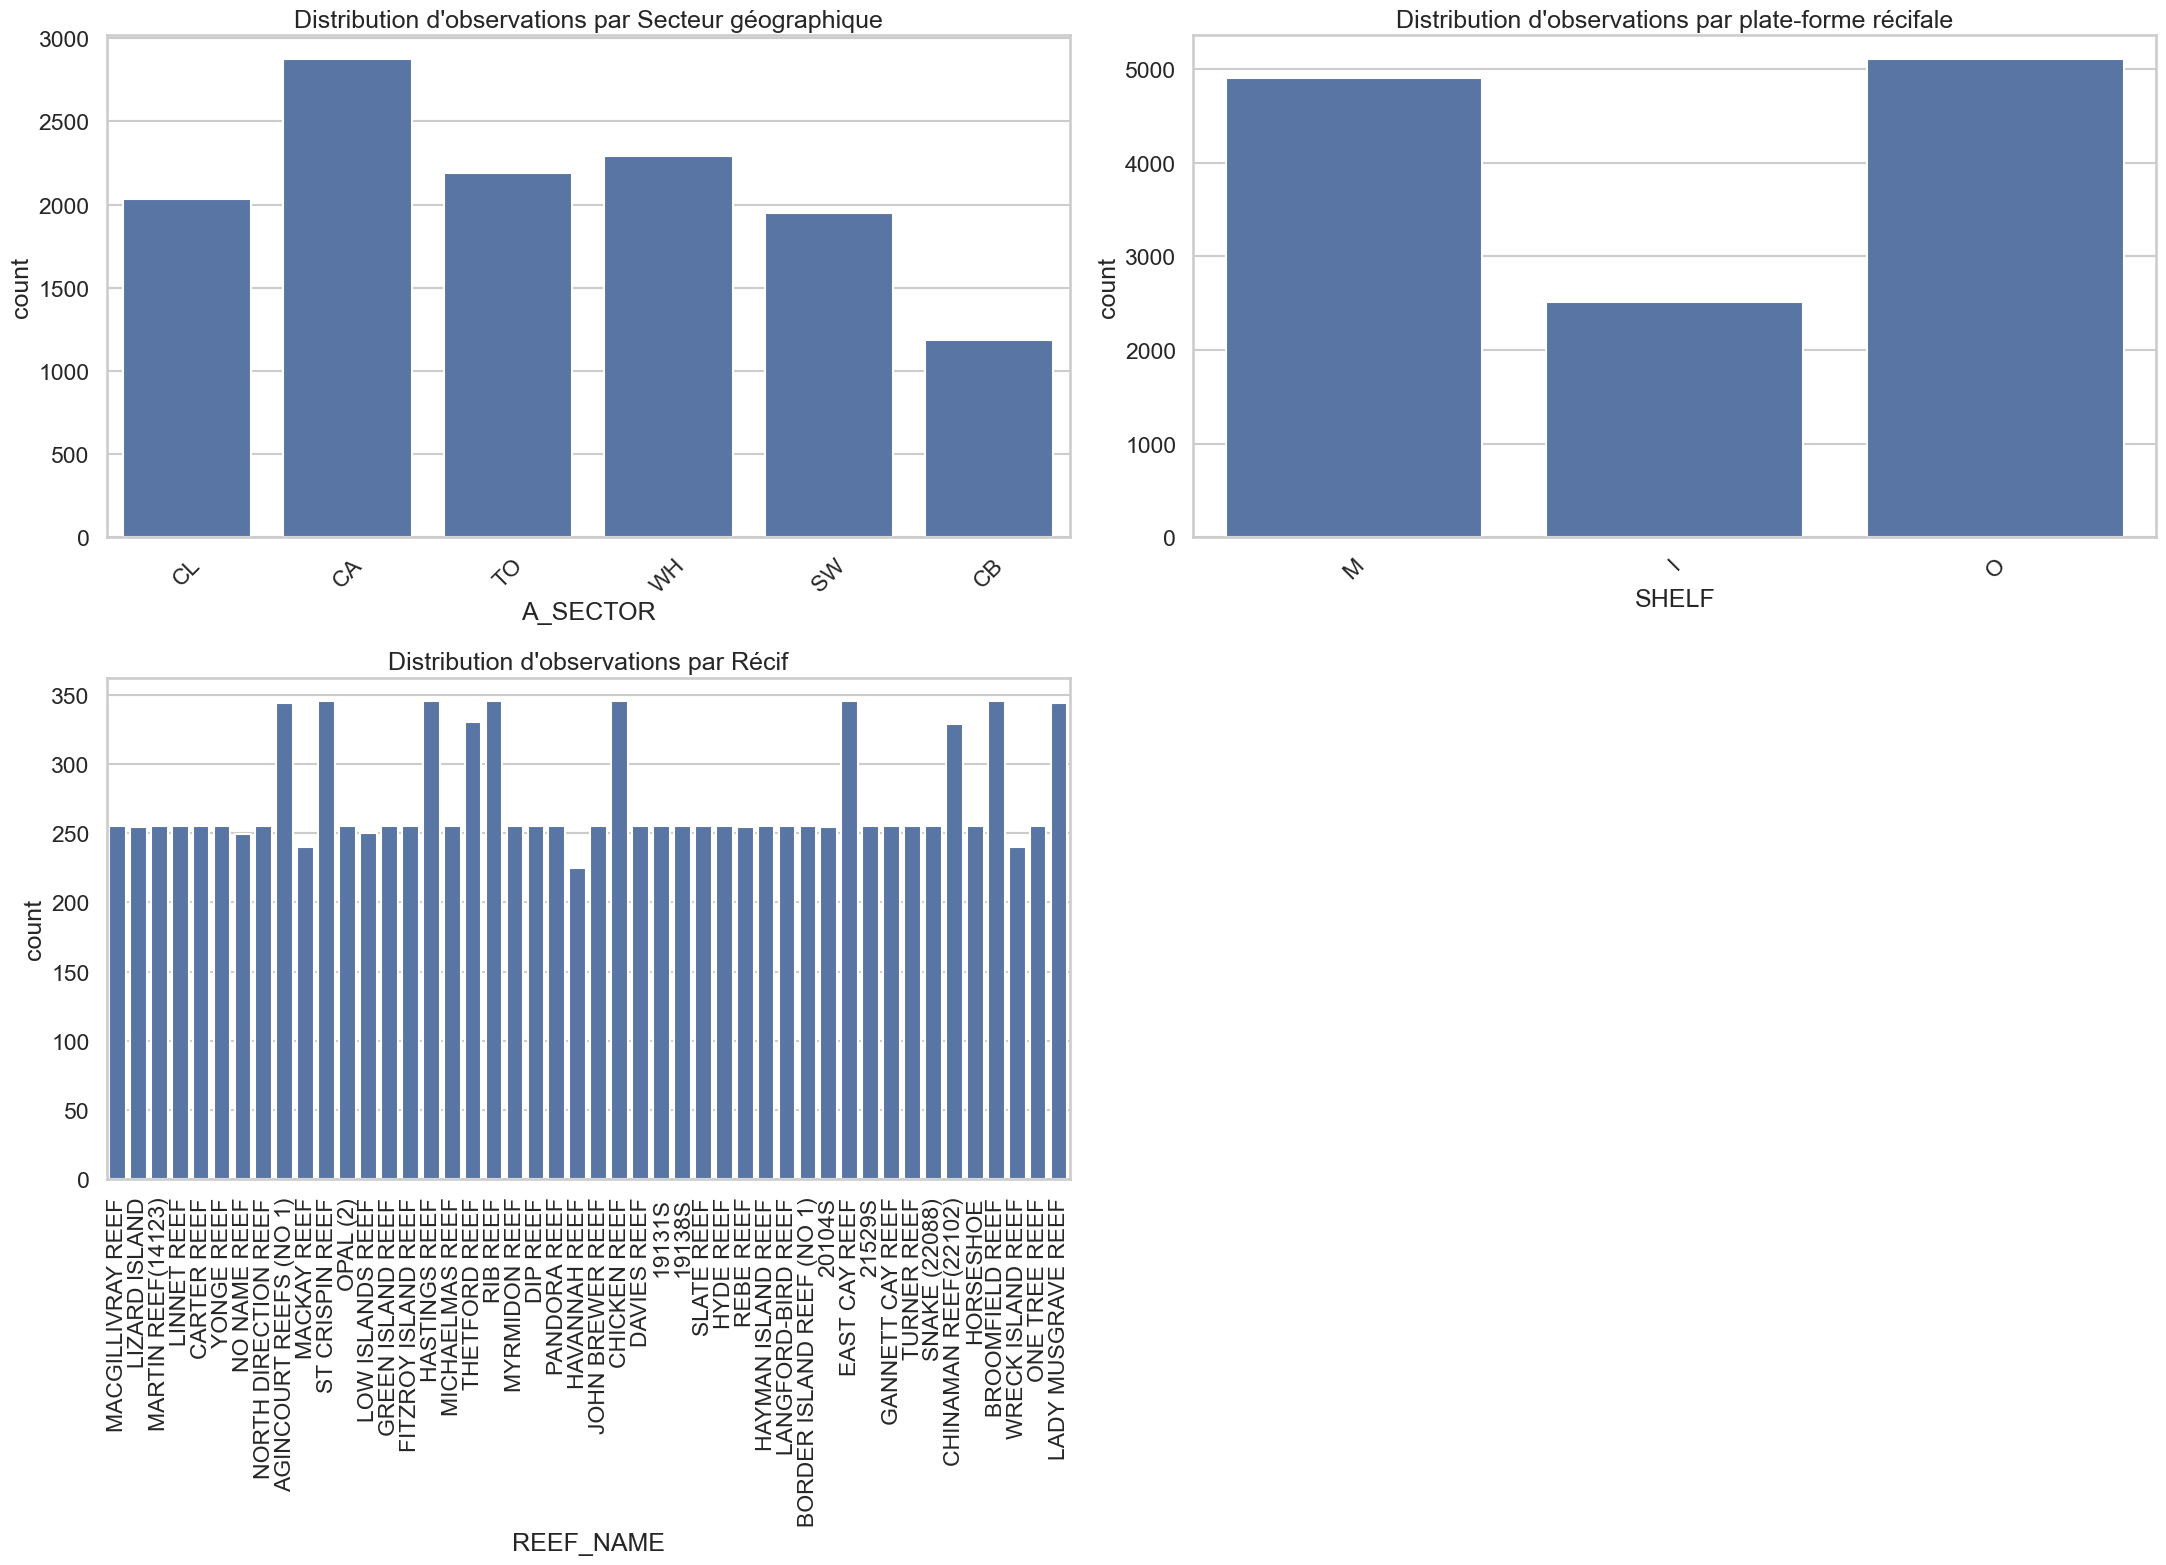

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(22, 16))

# Histogramme A_SECTOR
sns.countplot(x="A_SECTOR", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Distribution d'observations par Secteur géographique")
axes[0, 0].tick_params(axis='x', rotation=45)

# Histogramme SHELF
sns.countplot(x="SHELF", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Distribution d'observations par plate-forme récifale")
axes[0, 1].tick_params(axis='x', rotation=45)

# Histogramme REEF_NAME
sns.countplot(x="REEF_NAME", data=df, ax=axes[1, 0])
axes[1, 0].set_title("Distribution d'observations par Récif")
axes[1, 0].tick_params(axis='x', rotation=90)

# Laisser le dernier graphique vide 
axes[1, 1].axis('off') 

plt.tight_layout()
plt.show()


> En explorant ces variables (A_SECTOR, SHELF, REEF_NAME), nous observons que la distribution des observations est déséquilibrée entre les secteurs géographiques et les plateaux récifaux.
>
> De plus, la majorité des récifs présentent environ **250 observations**, tandis que seulement 8 récifs disposent d’environ **350 mesures**.
>
> Cela nous amène à formuler l’hypothèse suivante :
> - les récifs avec 350 observations seraient ceux pour lesquels des mesures sont disponibles chaque année,
> - tandis que les autres seraient échantillonnés une année sur deux.

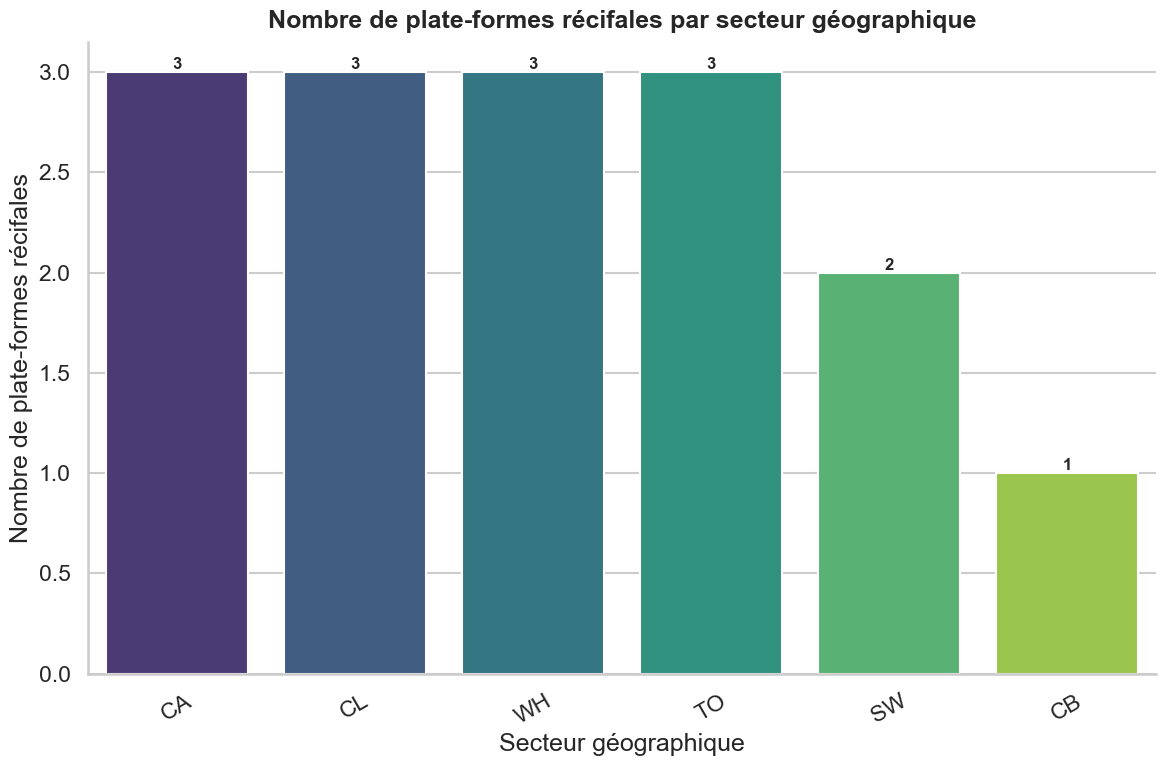

In [11]:
shelf_per_sector = (
    df.groupby("A_SECTOR")["SHELF"]
      .nunique()
      .reset_index()
      .rename(columns={"SHELF": "Nombre_de_SHELF"})
)

shelf_per_sector = shelf_per_sector.sort_values(
    by="Nombre_de_SHELF", ascending=False
)

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 8))

palette = sns.color_palette("viridis", len(shelf_per_sector))

ax = sns.barplot(
    data=shelf_per_sector,
    x="A_SECTOR",
    y="Nombre_de_SHELF",
    hue = "A_SECTOR",
    palette=palette
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_title("Nombre de plate-formes récifales par secteur géographique", pad=10, weight="bold")
ax.set_xlabel("Secteur géographique")
ax.set_ylabel("Nombre de plate-formes récifales")

plt.xticks(rotation=30)

sns.despine()

plt.tight_layout()
plt.show()

> En examinant la structure géographique, nous constatons qu’il existe entre **1** et **3** plateaux récifaux par secteur géographique.

SHELF
I    10
M    18
O    18
Name: REEF_NAME, dtype: int64
A_SECTOR
CA    10
CB     4
CL     8
SW     7
TO     8
WH     9
Name: REEF_NAME, dtype: int64


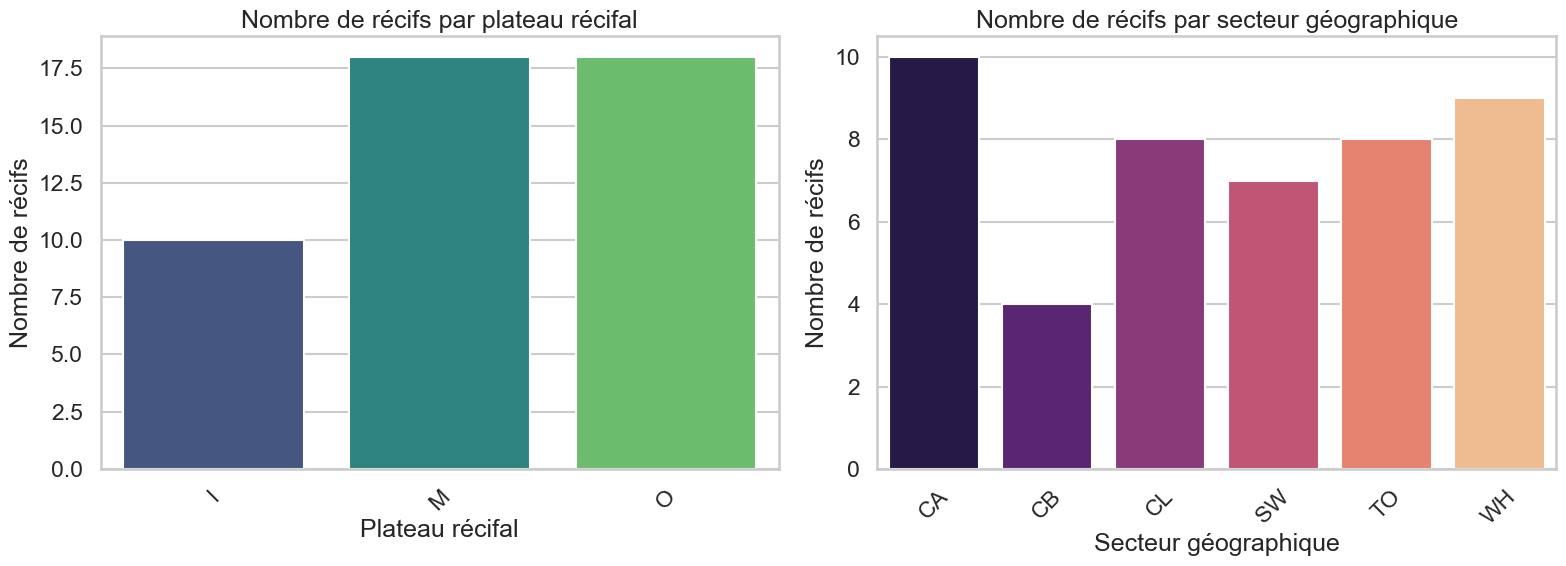

In [12]:
reef_per_shelf = df.groupby("SHELF")["REEF_NAME"].nunique()
print(reef_per_shelf)

reef_per_sector_shelf = df.groupby("A_SECTOR")["REEF_NAME"].nunique()
print(reef_per_sector_shelf)

df_shelf = reef_per_shelf.reset_index()
df_shelf.columns = ["SHELF", "N_REEFS"]

df_sector = reef_per_sector_shelf.reset_index()
df_sector.columns = ["A_SECTOR", "N_REEFS"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=df_shelf, 
    x="SHELF", 
    y="N_REEFS", 
    ax=axes[0], 
    hue="SHELF",      
    dodge=False,       
    palette="viridis",
    legend=False       
)
axes[0].set_title("Nombre de récifs par plateau récifal")
axes[0].set_xlabel("Plateau récifal")
axes[0].set_ylabel("Nombre de récifs")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    data=df_sector, 
    x="A_SECTOR", 
    y="N_REEFS", 
    ax=axes[1], 
    hue="A_SECTOR",
    dodge=False,
    palette="magma",
    legend=False
)
axes[1].set_title("Nombre de récifs par secteur géographique")
axes[1].set_xlabel("Secteur géographique")
axes[1].set_ylabel("Nombre de récifs")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> De plus, la répartition des récifs est également déséquilibrée, avec environ 10 à 18 récifs par plateau récifal et 4 à 10 récifs par secteur géographique.
>
> Sachant que chaque récif est associé à un unique **cluster**, analysons maintenant la répartition des récifs selon le type de corail (cluster).

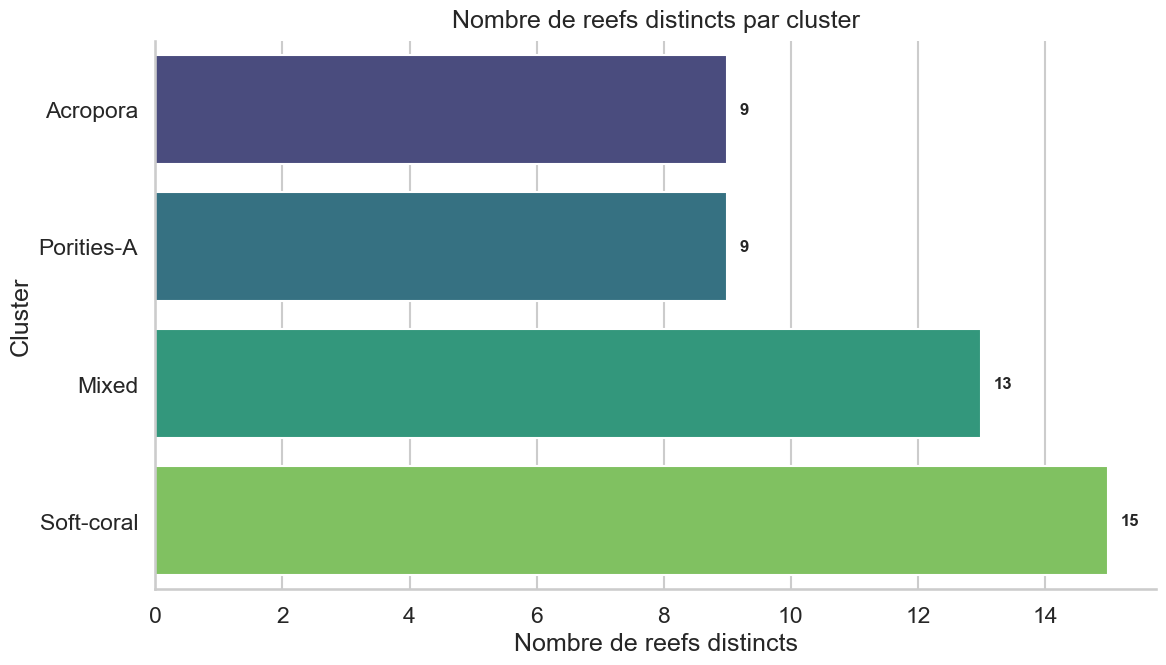

In [13]:
cluster_mapping = {'CL1' : 'Porities-A', 'CL2' : 'Mixed', 'CL3' : 'Soft-coral', 'CL4' : 'Acropora'}

df["Clust_names"] = df["CLUSTER"].map(cluster_mapping)

reef_per_cluster = (
    df.groupby("Clust_names")["REEF_NAME"]
      .nunique()
      .sort_values(ascending=True)
)

plt.figure(figsize=(12,7))

palette = sns.color_palette("viridis", len(reef_per_cluster))

ax = sns.barplot(
    x=reef_per_cluster.values,
    y=reef_per_cluster.index,
    hue=reef_per_cluster.index,
    palette=palette
)

for i, v in enumerate(reef_per_cluster.values):
    ax.text(
        v + 0.2,
        i,
        str(v),
        va="center",
        fontsize=12,
        fontweight="bold"
    )

ax.set_title("Nombre de reefs distincts par cluster", pad=10)
ax.set_xlabel("Nombre de reefs distincts")
ax.set_ylabel("Cluster")

sns.despine()
plt.tight_layout()
plt.show()

> Nous observons notamment que 15 récifs appartiennent au type soft coral.
>
> Nous disposons également de la variable `DISTURBANCE`, qui semble décrire les perturbations affectant les récifs (étoiles de mer, cyclones, érosion, etc.). **Il est donc pertinent d’évaluer si cette variable peut être intégrée dans notre analyse afin de prédire la couverture corallienne**.

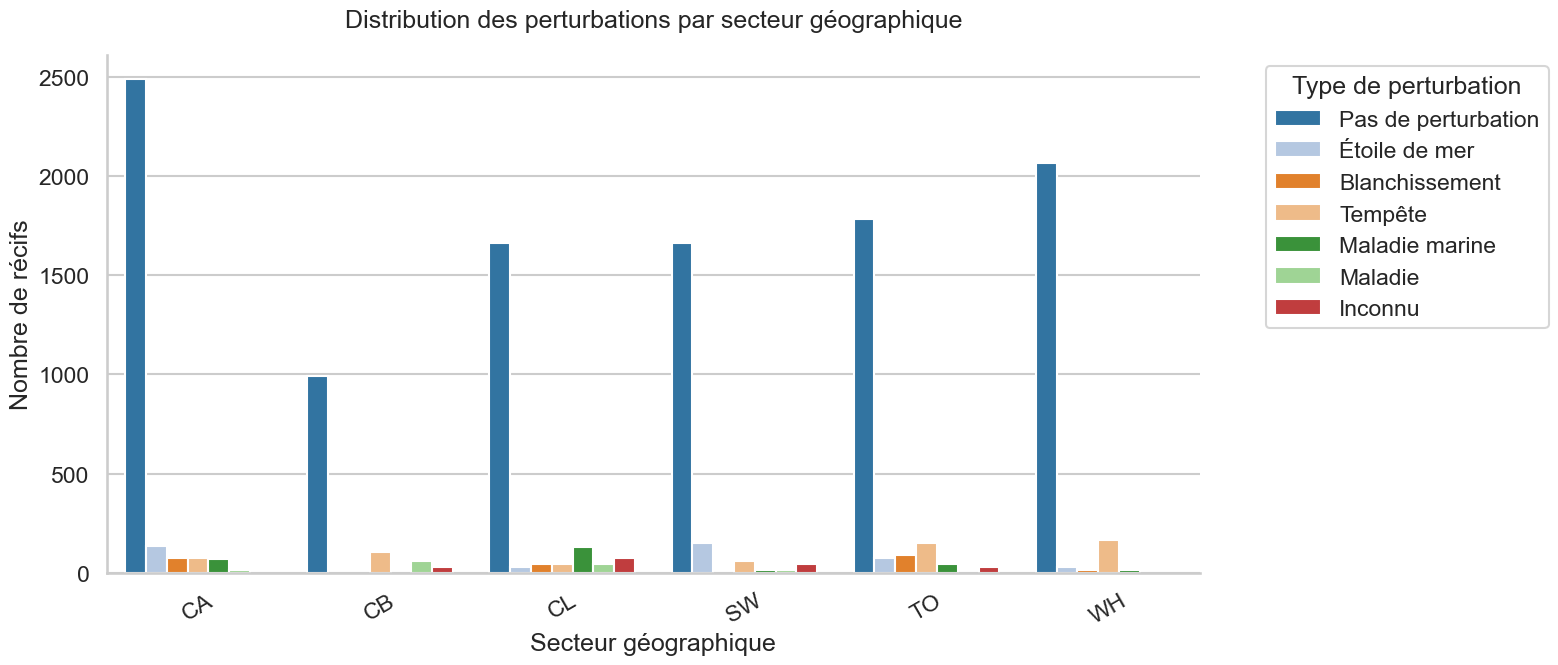

In [14]:
disturbance_mapping = {
    'N': 'Pas de perturbation',
    'U': 'Inconnu',
    'S': 'Tempête',
    'C': 'Étoile de mer',
    'M': 'Maladie marine',
    'B': 'Blanchissement',
    'D': 'Maladie'
}


df['DISTURBANCE_LABEL'] = df['DISTURBANCE'].map(disturbance_mapping)


disturbance = (
    df.groupby('A_SECTOR')['DISTURBANCE_LABEL']
      .value_counts()
      .reset_index(name='count')
)

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(16,7))

unique_labels = disturbance['DISTURBANCE_LABEL'].unique()
palette = sns.color_palette("tab20", len(unique_labels))

ax = sns.barplot(
    data=disturbance,
    x='A_SECTOR',
    y='count',
    hue='DISTURBANCE_LABEL',
    palette=palette
)

plt.xticks(rotation=30)

plt.legend(title="Type de perturbation", bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_title("Distribution des perturbations par secteur géographique", pad=20)
ax.set_xlabel("Secteur géographique")
ax.set_ylabel("Nombre de récifs")

sns.despine()
plt.tight_layout()
plt.show()

> Cependant, après exploration, nous constatons que dans la majorité des cas, **cette variable est peu renseignée** (valeurs “No disturbance” ou “No data”). En raison de ce caractère très lacunaire, **il semble difficile de l’intégrer de manière fiable dans un modèle prédictif** (Nous devons valider cela avec le commanditaire).
>
> Par ailleurs, la couverture corallienne peut dépendre de plusieurs facteurs. Elle peut varier selon le type de corail (certains types ayant tendance à croître, d’autres à diminuer), mais également selon le plateau récifal. En effet, certains plateaux peuvent offrir de meilleures conditions de croissance, tandis que d’autres peuvent avoir subi des perturbations importantes limitant le développement du corail.
>
## Analyse temporelle
>
> Pour conclure cette phase exploratoire, intéressons-nous à l’évolution de la **variable cible** (couverture corallienne) **dans le temps**, à travers les clusters, les plateaux récifaux et les récifs.
>
> Commençons par analyser l’évolution selon le type de corail. 

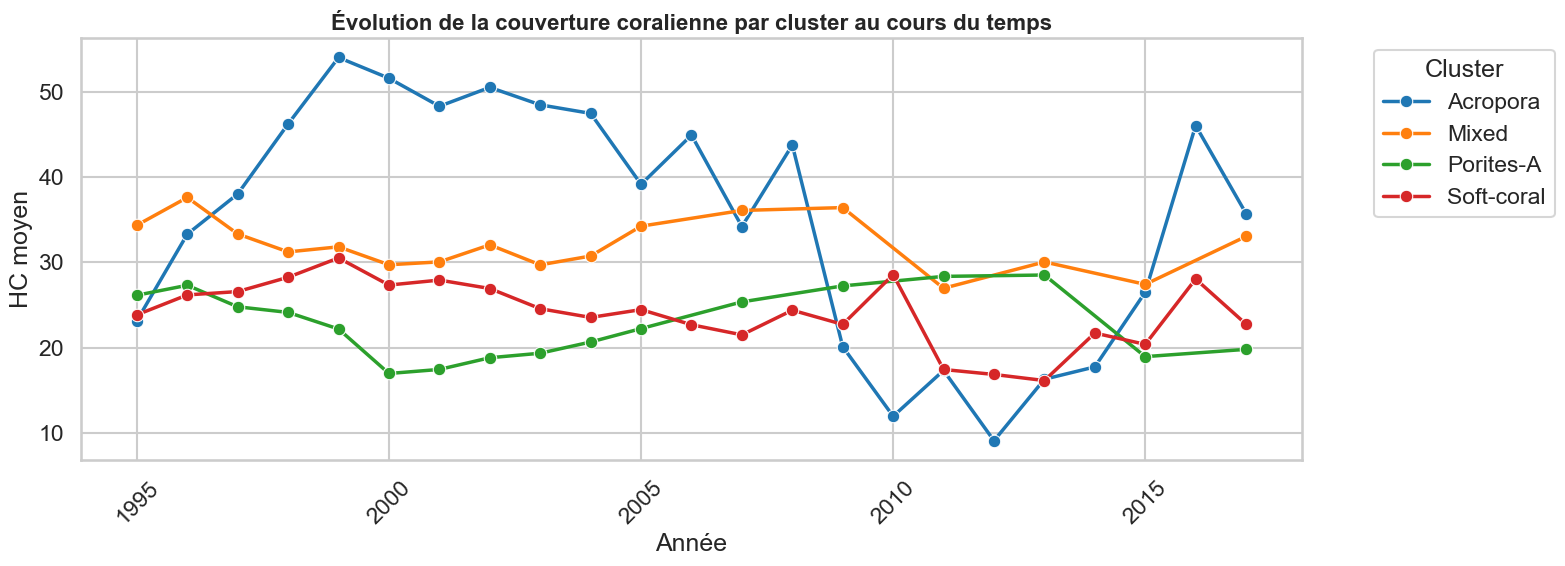

In [15]:
Clust_dict = {
    'CL1':'Porites-A',
    'CL2':'Mixed',
    'CL3':'Soft-coral',
    'CL4':'Acropora'
}

df['Clust_names'] = df['CLUSTER'].map(Clust_dict)


table = df.groupby(["REPORT_YEAR", "Clust_names"])["HC"].mean().reset_index()
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=table,
    x="REPORT_YEAR",
    y="HC",
    hue="Clust_names",
    marker="o",
    linewidth=2.5,
    palette="tab10"
)

plt.title("Évolution de la couverture coralienne par cluster au cours du temps", fontsize=16, weight="bold")
plt.xlabel("Année")
plt.ylabel("HC moyen")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

> Ensuite, examinons l’évolution de la couverture corallienne à travers les plateaux. 


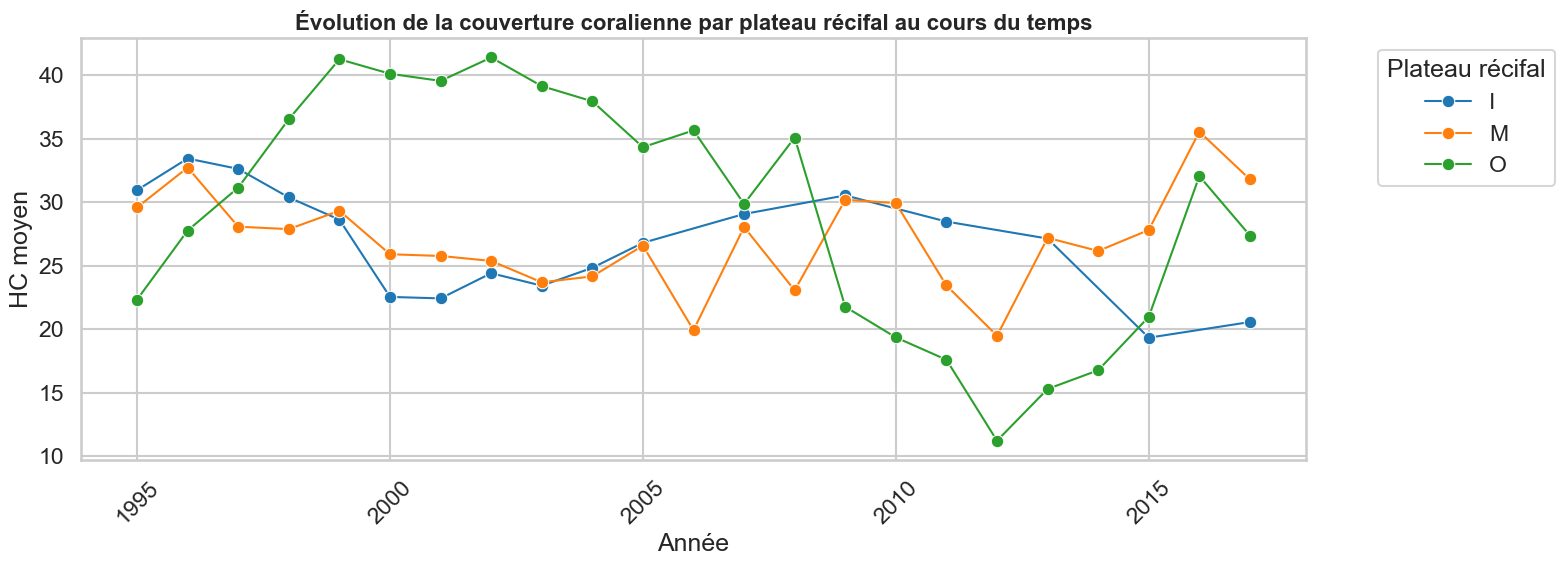

In [16]:
table = df.groupby(["REPORT_YEAR", "SHELF"])["HC"].mean().reset_index()
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=table,
    x="REPORT_YEAR",
    y="HC",
    hue="SHELF",
    marker="o",
    linewidth=1.5,
    palette="tab10"
)

# Personnalisation
plt.title("Évolution de la couverture coralienne par plateau récifal au cours du temps", fontsize=16, weight="bold")
plt.xlabel("Année")
plt.ylabel("HC moyen")
plt.legend(title="Plateau récifal", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

> Ensuite, examinons l’évolution en fonction des **zones protégées**. On pourrait s’attendre à une évolution plus favorable dans ces zones.

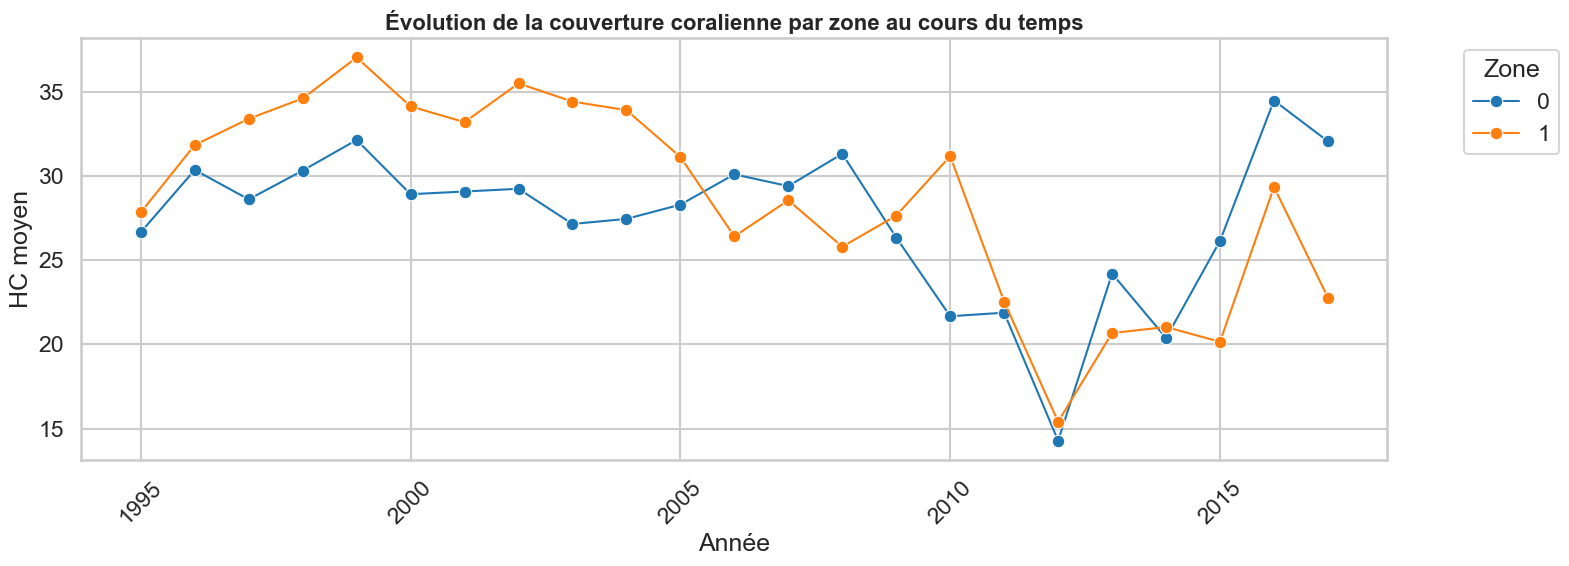

In [17]:
df['zone'] = (df.iZONE.values + df.sZONE.values>0)*1

table = df.groupby(["REPORT_YEAR", "zone"])["HC"].mean().reset_index()
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=table,
    x="REPORT_YEAR",
    y="HC",
    hue="zone",
    marker="o",
    linewidth=1.5,
    palette="tab10"
)

plt.title("Évolution de la couverture coralienne par zone au cours du temps", fontsize=16, weight="bold")
plt.xlabel("Année")
plt.ylabel("HC moyen")
plt.legend(title="Zone", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

> Toutefois, aucune différence claire n’apparaît entre les zones protégées et non protégées.
>
> Enfin, analysons les tendances au niveau des **récifs**. 

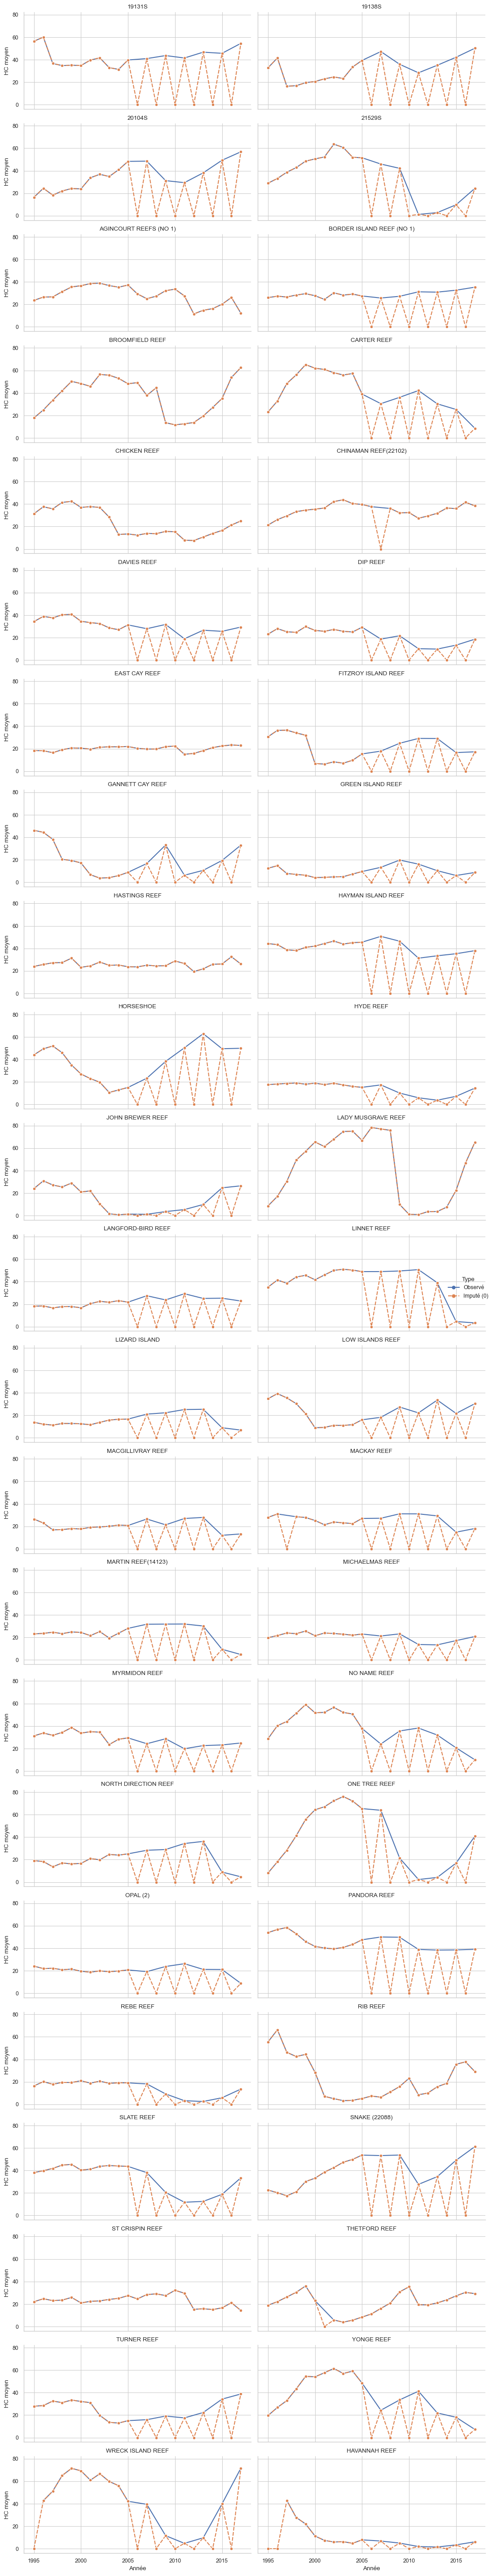

In [18]:

table = df.groupby(["REPORT_YEAR", "REEF_NAME"])["HC"].mean().reset_index()
table["Type"] = "Observé"

all_years = sorted(df["REPORT_YEAR"].unique())
all_reefs = df["REEF_NAME"].unique()

full_index = pd.MultiIndex.from_product(
    [all_years, all_reefs],
    names=["REPORT_YEAR", "REEF_NAME"]
)

table_full = (
    table.drop(columns="Type")
    .set_index(["REPORT_YEAR", "REEF_NAME"])
    .reindex(full_index)
    .reset_index()
)

table_full["HC"] = table_full["HC"].fillna(0)
table_full["Type"] = "Imputé (0)"

plot_data = pd.concat([table, table_full], ignore_index=True)


sns.set_theme(style="whitegrid", context="paper")

g = sns.relplot(
    data=plot_data,
    x="REPORT_YEAR",
    y="HC",
    col="REEF_NAME",
    col_wrap=2,          
    kind="line",
    hue="Type",
    style="Type",
    height=2.5,
    aspect=2,
    linewidth=1.5,
    marker="o"
)

g.set_axis_labels("Année", "HC moyen")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

> Nous constatons une **forte variabilité d’un récif à l’autre**.
>
> Nous observons également que, **pour de nombreux récifs, les mesures ne sont disponibles qu’une année sur deux**, ce qui complique l’analyse temporelle.


# Conclusion

## Points à discuter avec les commanditaires

> Lors de l’exploration des données, plusieurs problématiques ont été identifiées et nécessitent des clarifications avant de poursuivre l’analyse.
>
> 1) Tout d’abord, nous avons observé un nombre important de valeurs codées `-999`, qui semblent correspondre à des données manquantes.
> - Il est essentiel de définir une stratégie de traitement adaptée : suppression, imputation, remplacement par 0 ou autre méthode.
>
> 2) Ensuite, une clarification est nécessaire concernant les variables `COVER` et `HC` : représentent-elles la même mesure ? Cela semble probable, mais doit être confirmé.
>
> 3) Par ailleurs, la structure des variables spatiales doit être précisée. Nous supposons que :
> - `A_SECTOR` correspond à un secteur géographique
> - `SHELF` à un plateau récifal
> - `REEF_NAME` au récif
>
> Dans cette hiérarchie, chaque récif esr associé à un unique cluster, ce qui reste à valider.
>
> Des questions subsistent également sur la **méthodologie de mesure** :
>
> **Comment les mesures sont-elles réalisées précisément ?**
> 
> Est-il correct de supposer qu’un récif est divisé en **3 sites**, eux-mêmes subdivisés en **5 transects**, avec une mesure attendue par transect chaque année ?
>
> **Pourquoi certaines séries sont-elles annuelles alors que d’autres sont biennales (une année sur deux), notamment à partir de 2005 ?**
>
> Enfin, **les objectifs de l’étude doivent être clarifiés** :
>
> - À quel niveau doit-on prédire la couverture corallienne : secteur, plateau récifal ou récif ?
> - Comment traiter les récifs présentant des données manquantes ou des mesures intermittentes ?
>
> Concernant la variable `DISTURBANCE`, doit-elle être intégrée dans l’analyse malgré son caractère incomplet ?
>
> Plus globalement, il est important de définir **comment intégrer les différentes dimensions géographiques et écologiques dans la modélisation**. L’évolution de la couverture corallienne peut en effet dépendre simultanément du type de corail, du récif et du plateau récifal, avec des interactions potentielles entre ces facteurs.
>
> En résumé, avant de poursuivre, il est indispensable de clarifier :
> - le traitement des données manquantes
> - la structure spatiale des données
> - la méthodologie de mesure
> - le niveau de prédiction attendu
> - et l’utilisation des variables de perturbation afin de garantir la pertinence et la robustesse de l’analyse.